# 66% Balanced Consensus: Fine-tuning BERT as a Financial Sentiment Classifier
## 30 epochs with model checkpointing based on validation F1

## [See Weights and Biases Report](https://api.wandb.ai/links/iankelk/8b3mzk8t)

This document provides an explanation of the python script used to train a classifier on top of a BERT model via fine-tuning. The task is financial sentiment analysis, where sentences are classified into three sentiments: negative, neutral, and positive.

## Dataset

The dataset is [hosted on Hugging Face,](https://huggingface.co/datasets/takala/financial_phrasebank) where you can find further information on its curation, motivation, and annotation.

### Overview

The dataset consists of 4846 lines, each containing a financial text sentence and its corresponding sentiment, separated by an '@' symbol. The sentiment can belong to one of three categories: Negative, Neutral, or Positive, and is distributed as:

- Neutral: 2879 entries (59%)
- Positive: 1363 entries (28%)
- Negative: 604 entries (12.4%)

### Data Fields

- **sentence**: A tokenized line from the dataset.
- **label**: A label representing the sentence class as a string: 'positive', 'negative', or 'neutral'.

### Data Splits

Although the dataset does not come with predefined training/validation/test splits, the sentences are categorized into different configurations based on the degree of agreement among the annotators:

- **sentences_50agree**: Number of instances with >= 50% annotator agreement - 4846 sentences
- **sentences_66agree**: Number of instances with >= 66% annotator agreement - 4217 sentences
- **sentences_75agree**: Number of instances with >= 75% annotator agreement - 3453 sentences
- **sentences_allagree**: Number of instances with 100% annotator agreement - 2264 sentences

For this project, we use the `sentences_50agree` configuration comprising of 4846 instances and manually split it into training, validation, and testing sets in a 70-15-15 proportion.

All sentences in the dataset are limited to fewer than 512 tokens, in accordance with the BERT model's input constraints.

## Imports and System Setup

The first part of the code includes importing necessary modules and setting up the PyTorch environment to recognize accessible GPU devices (or fall back to the CPU if no GPU is available).

## Metrics

The model’s performance after training is evaluated based on accuracy and F1 score. Accuracy measures the proportion of correct predictions, while the F1 score provides a harmonic mean between precision and recall, hammered down for individual classes.

F1 score is calculated after each epoch by a small evaluation helper that uses the Scikit-learn function `f1_score()` for calculation.

We took the extra step of tracking the F1 score for the validation set for a few reasons due to using a financial dataset:

* Handling Imbalance: Financial datasets often exhibit class imbalance. For instance, genuine transactions significantly outnumber fraudulent ones. Accuracy can be misleading in such cases, making F1 a more balanced metric as it considers both precision and recall.
* Balancing Costs: Both false negatives (e.g., overlooking a negative sentiment) and false positives (e.g., misclassifying a neutral statement as negative) have implications. The F1 score ensures a balance between reducing these two error types.
* Threshold Tuning: Financial decisions can involve adjustable thresholds. The F1 score can guide optimization, ensuring neither precision nor recall is neglected.

## Wandb

[Wandb (Weights & Biases)](https://wandb.ai/site) is used for experiment tracking.

## Preprocessing

The data is read from the `.txt` file. The file encoding is first detected using the `chardet` library, and then the data is loaded into a pandas DataFrame using the detected encoding. The DataFrame contains two columns: `sentence` and `label`.

Then the data is split into train, validation, and test sets, stratifying on the label to respect the original distribution of classes in the dataset.

The `BertTokenizer` is used to encode the sentences into format suitable for the BERT model. `truncation=True` and padding to a fixed maximum length ensures that all sequences are of the same length.

The tokenized sentence encodings and the corresponding labels are wrapped into a custom PyTorch `Dataset` subclass and iterated over via `DataLoader` objects during training and evaluation.

## Model Creation

The existing BERT model ('bert-base-uncased') from HuggingFace's transformer models is loaded for sequence classification with 3 labels (negative, neutral, positive).

## Model Compilation and Training

We compile the model with the Adam optimizer, SparseCategoricalCrossentropy loss, and accuracy as a metric. We use SparseCategoricalCrossentropy because this is a multi-class classification problem with three integer labels (negative, neutral, positive), not one-hot vectors. Concretely, for each input example the model outputs a length-3 vector of raw scores called logits, one score per class. The loss function then applies a softmax to those logits to turn them into a probability distribution over the three classes.

Given a true label $y \in {0,1,2}$ (encoded as a single integer, not a one-hot vector), the loss for that example is the negative log of the predicted probability assigned to class $y$. At inference time, we take the argmax of the logits (or of the softmax probabilities) to pick the predicted class: the index of the largest score corresponds to “negative”, “neutral”, or “positive” respectively.

A Wandb run is initialized, and the data is fit on the model using a batch size of 8 for 30 epochs. The validation data and the custom F1 score calculation callback are also passed in the fit method, as is early stopping.

## Evaluation

The model is evaluated on the test set. Classification report and F1 score are printed to show detailed information about performance on all three categories. The F1 score is also logged to the Wandb run.

In [ ]:
!pip install wandb

In [ ]:
!pip install transformers

## Install & Imports

In [ ]:
# These aren't needed when running in Google Colab, but
# you might need to install these if running locally
# !pip install transformers wandb chardet scikit-learn

import os
import io
import math
import random
import contextlib

import chardet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)

import wandb

## Config, seed, device

In [ ]:
# Dataset & run config
WHICH_DATASET = "Sentences_66Agree.txt"    # same as in the TF version
SAVE_PATH = "./finetuned_bert_66_30"      # where to save best model
RUN_NAME = f"bert_finetune_66_agree_{WHICH_DATASET.split('.')[0]}"
PROJECT_NAME = "bert-sentiment"

seed_val = 42

# Reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed_val)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Prepare Data

## Overview

The varying levels of annotator agreements creates an unusual challenge. The aim is to create a train, test, and validation split that does not bias the model towards obvious sentiments. This guide will describe each step in the data splitting process.

## Step 1: Load the Data

Firstly we load the dataset files (which are text files in this case). Considering the possibility that these text files might have different encodings (they initially crashed the program as they use `ISO-8859-1`), we use Python's `chardet` library to detect the encoding before reading the file. This ensures that the loading of files doesn't fail due to encoding issues. The data is then shuffled randomly. The shuffling was an easy thing to miss, as previously we had used `train_test_split` from `scikit-learn` to split the data, and it had automatically shuffled the data. The data actually comes nearly sorted by sentiment, so without shuffling the model can't be fine-tuned at all.

The files are read in the following way:
- Every sentence in the dataset is separated by an '@' delimiter.
- There are no headers in the files so they are assigned later as ['sentence', 'label'].
- We use pandas' `read_csv` function to read these files.

## Step 2: Create a Subset from 'sentences_50agree'

The `sentences_50agree` dataset is the largest and most diverse dataset. To avoid overfitting and create a diverse validation set, we create a subset from this dataframe that will later be used for validation/testing. This subset is the same size as the train set.

## Step 3: Split the Subset into Validation and Test Sets

The subset created from `sentences_50agree` is split into validation and test sets. Here, a stratified sampling is performed to ensure that the split datasets have instances of each class ('positive', 'negative', and 'neutral') in proportions close to their original distribution in the parent dataset. The dataset is split in such way that 31% data is used for validation/testing. We choose 31% as this seems to result in the closest to a 70/15/15 train/validate/test split once the datasets have been assembled.

**Rationale for the 70/15/15 Split:**

We specifically chose a 70/15/15 split over other common splits (like 80/10/10) due to class imbalance. The 'Negative' class constitutes only ~12% of the dataset. A smaller test set (e.g., 10%) would result in only ~50 negative examples. This is too small a sample size to reliably evaluate the model's performance (F1 score) on that specific class, as a few misclassifications could drastically swing the metrics. The 15% split ensures we have a statistically significant number of examples (approx. 80) for the minority class in both validation and test sets, providing a more stable evaluation.

## Step 4: Update the Training Set

After obtaining the validation and test sets, we remove sentences present in these sets from the training set. This is done to avoid data leakage and ensure that the model doesn't see any sentence in the training phase that it would later encounter in the validation/testing phase.

## Step 5: Further Divide the Validation and Test Sets

The validation/test set subset is then divided equally into two parts: one part forms the validation set and the other part forms the test set.

## Step 6: Output the Sizes and Percentages

Finally, after creating all the datasets, we output the sizes of the train, validation, and test datasets along with their respective percentages to make sure that the classes are as balanced as they can be given the data.

This completes our data splitting process ensuring that we have a good mix of data in each dataset and our model does not get biased towards the easy-to-identify financial sentiments.

## Load & split data

In [ ]:
def load_data(data_path: str, seed: int) -> pd.DataFrame:
    """Load the ISO-8859-1 text files with '@' delimiter and shuffle."""
    raw_data = open(data_path, "rb").read()
    result = chardet.detect(raw_data)
    encoding = result["encoding"]
    print("Encoding for:", data_path, "is:", encoding)

    df = pd.read_csv(
        data_path,
        delimiter="@",
        header=None,
        names=["sentence", "label"],
        encoding=encoding,
    )
    # Shuffle
    return df.sample(frac=1, random_state=seed).reset_index(drop=True)

# Load datasets
df_50agree = load_data("Sentences_50Agree.txt", seed_val)
train_df = load_data(WHICH_DATASET, seed_val)

original_50agree_count = len(train_df)

# Subset from sentences_50agree equal to train size
subset_50agree = df_50agree.sample(n=len(train_df), random_state=seed_val)

# Randomly choose 31% of this subset for validation/test (stratified)
_, valid_test_subset = train_test_split(
    subset_50agree,
    test_size=0.31,
    random_state=seed_val,
    stratify=subset_50agree["label"],
)

# Remove those sentences from the train set to avoid leakage
train_df = train_df[~train_df["sentence"].isin(valid_test_subset["sentence"])]

# Split validation/test subset in half (stratified)
valid_df, test_df = train_test_split(
    valid_test_subset,
    test_size=0.5,
    random_state=seed_val,
    stratify=valid_test_subset["label"],
)

# Show sizes
total_size = len(train_df) + len(valid_df) + len(test_df)
print(f"\nSize of Train set: {len(train_df)} ({len(train_df)/total_size*100:.2f}%)")
print(f"Size of Validation set: {len(valid_df)} ({len(valid_df)/total_size*100:.2f}%)")
print(f"Size of Test set: {len(test_df)} ({len(test_df)/total_size*100:.2f}%)")

Encoding for: Sentences_50Agree.txt is: ISO-8859-1
Encoding for: Sentences_66Agree.txt is: ISO-8859-1

Size of Train set: 3084 (70.22%)
Size of Validation set: 654 (14.89%)
Size of Test set: 654 (14.89%)


## Check out the distribution of the classes to ensure they look balanced across datasets

In [ ]:
print("Training set class counts:")
print(train_df["label"].value_counts(), "\n")

print("Validation set class counts:")
print(valid_df["label"].value_counts(), "\n")

print("Test set class counts:")
print(test_df["label"].value_counts())

Training set class counts:
label
neutral     1854
positive     852
negative     378
Name: count, dtype: int64 

Validation set class counts:
label
neutral     388
positive    186
negative     80
Name: count, dtype: int64 

Test set class counts:
label
neutral     388
positive    185
negative     81
Name: count, dtype: int64


## Tokenizer, label mapping, PyTorch Dataset

In [ ]:
# Load the BERT tokenizer. This converts raw text into token IDs
# compatible with the "bert-base-uncased" model.
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Map human-readable sentiment labels to integer IDs.
label2id = {"negative": 0, "neutral": 1, "positive": 2}
# Invert the mapping so we can go from ID -> label name if needed.
id2label = {v: k for k, v in label2id.items()}

class FinancialSentimentDataset(Dataset):
    """
    Custom PyTorch Dataset for financial-sentiment classification.

    Expects a DataFrame with columns:
      - 'sentence': the raw text
      - 'label':   string label in {'negative', 'neutral', 'positive'}
    """

    def __init__(self, df: pd.DataFrame, tokenizer, label2id, max_length: int = 128):
        # Store the sentences as a plain Python list for fast indexing.
        self.texts = df["sentence"].tolist()
        # Convert string labels to integer IDs using the label2id mapping.
        self.labels = [label2id[l] for l in df["label"].tolist()]
        # Save tokenizer and maximum sequence length.
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        # Required method: returns the total number of examples.
        return len(self.texts)

    def __getitem__(self, idx):
        """
        Given an index `idx`, return a single example as a dict of tensors:
          - input_ids
          - attention_mask
          - labels
        """
        # Get the text and label for this index.
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize the text:
        #  truncation=True: cut off sequences longer than max_length
        #  padding="max_length": pad shorter sequences up to max_length
        #  return_tensors="pt": return PyTorch tensors
        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        # The tokenizer returns tensors with an extra batch dimension (size 1),
        # so we squeeze(0) to remove that and get a 1D tensor.
        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            # Convert the Python int label to a torch tensor of dtype long,
            # which is what PyTorch's CrossEntropyLoss expects.
            "labels": torch.tensor(label, dtype=torch.long),
        }
        return item


# Instantiate Dataset objects for train, validation, and test splits.
train_dataset = FinancialSentimentDataset(train_df, tokenizer, label2id, max_length=128)
val_dataset   = FinancialSentimentDataset(valid_df, tokenizer, label2id, max_length=128)
test_dataset  = FinancialSentimentDataset(test_df, tokenizer, label2id, max_length=128)

# Mini-batch size for training/eval.
batch_size = 8

# Wrap each Dataset in a DataLoader:
#  train_loader shuffles data each epoch
#  val_loader and test_loader keep a fixed order
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

## Model, optimizer, scheduler, W&B

In [ ]:
# Log in to Weights & Biases so we can track this run (loss, accuracy, F1, etc.).
wandb.login()

# Load a pretrained BERT model for sequence classification.
#  "bert-base-uncased" is the base English model with lowercased vocabulary.
#  num_labels=3 because we have 3 sentiment classes.
#  id2label and label2id tell the model how to map IDs <-> string labels.
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

# Move the model to the selected device (GPU if available, otherwise CPU).
model.to(device)

# Set up optimizer and learning rate.
# AdamW is a popular choice for fine-tuning transformer models.
learning_rate = 3e-5 # 0.000005
optimizer = AdamW(model.parameters(), lr=learning_rate)

# Training setup: number of epochs and total update steps.
num_epochs = 30
total_steps = len(train_loader) * num_epochs

# Use a 10% warmup: start with a small LR that ramps up, then decays.
warmup_steps = int(0.1 * total_steps)

# Linear learning rate schedule with warmup:
#  LR increases linearly during warmup_steps
#  then decreases linearly to 0 by total_steps
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

# Initialize a W&B run for this experiment.
wandb.init(project=PROJECT_NAME, name=RUN_NAME)

# Tell W&B to watch the model so it logs gradients, parameter histograms, etc.
wandb.watch(model, log="all")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: iankelk (ac215-saladeers) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training loop with validation F1 checkpointing

In [ ]:
def evaluate(model, data_loader):
    """Run evaluation on a DataLoader and return loss, accuracy, weighted F1."""
    # Put model in evaluation mode (disables dropout, etc.).
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    # Lists to accumulate all predictions and labels for F1 computation.
    all_preds = []
    all_labels = []

    # Cross-entropy loss for multi-class classification.
    loss_fn = torch.nn.CrossEntropyLoss()

    # Disable gradient tracking during evaluation for speed and memory.
    with torch.no_grad():
        for batch in data_loader:
            # Move batch to the correct device.
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # Forward pass through the model.
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )
            loss = outputs.loss
            logits = outputs.logits

            # Accumulate loss, scaled by batch size so we can average later.
            total_loss += loss.item() * labels.size(0)

            # Predicted class is the argmax over logits.
            preds = torch.argmax(logits, dim=-1)

            # Count how many predictions were correct.
            total_correct += (preds == labels).sum().item()
            total_examples += labels.size(0)

            # Collect predictions and labels for F1.
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Average loss across all examples.
    avg_loss = total_loss / total_examples
    # Overall accuracy.
    accuracy = total_correct / total_examples
    # Weighted F1: weights each class by its support.
    f1 = f1_score(all_labels, all_preds, average="weighted")

    return avg_loss, accuracy, f1


# Best validation F1 seen so far (for checkpointing / early stopping).
best_val_f1 = 0.0
# Early-stopping patience (in epochs).
patience = 10
# How many epochs since the last improvement in val F1.
epochs_no_improve = 0

# Histories for plotting / inspection later.
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []
val_f1_history = []

# Main training loop over epochs.
for epoch in range(1, num_epochs + 1):
    print(f"\nEpoch {epoch}/{num_epochs}")
    # Switch model to training mode (enables dropout, etc.).
    model.train()

    total_train_loss = 0.0
    total_train_correct = 0
    total_train_examples = 0

    # Iterate over mini-batches from the training DataLoader.
    for step, batch in enumerate(train_loader):
        # Move batch to device.
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Zero out gradients from the previous step.
        optimizer.zero_grad()

        # Forward pass.
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )
        loss = outputs.loss
        logits = outputs.logits

        # Backpropagate to compute gradients.
        loss.backward()

        # Clip gradients to avoid exploding gradients.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update parameters and take one scheduler step.
        optimizer.step()
        scheduler.step()

        # Track training loss and accuracy.
        batch_size_curr = labels.size(0)
        total_train_loss += loss.item() * batch_size_curr

        preds = torch.argmax(logits, dim=-1)
        total_train_correct += (preds == labels).sum().item()
        total_train_examples += batch_size_curr

        # Optional progress printout every 50 steps.
        if (step + 1) % 50 == 0:
            print(
                f"  Step {step+1}/{len(train_loader)} "
                f" - batch loss: {loss.item():.4f}"
            )

    # Compute average training loss / accuracy for this epoch.
    avg_train_loss = total_train_loss / total_train_examples
    train_accuracy = total_train_correct / total_train_examples

    # Run validation at the end of the epoch.
    val_loss, val_accuracy, val_f1 = evaluate(model, val_loader)

    # Save histories for later plotting.
    train_loss_history.append(avg_train_loss)
    val_loss_history.append(val_loss)
    train_acc_history.append(train_accuracy)
    val_acc_history.append(val_accuracy)
    val_f1_history.append(val_f1)

    print(
        f"Epoch {epoch}: "
        f"train_loss={avg_train_loss:.4f}, train_acc={train_accuracy:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_accuracy:.4f}, val_f1={val_f1:.4f}"
    )

    # Log metrics to Weights & Biases.
    wandb.log(
        {
            "epoch": epoch,
            "train_loss": avg_train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "val_f1_score": val_f1,
        }
    )

    # Check if this epoch improved the best validation F1.
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        print(f"  New best val F1: {best_val_f1:.4f}. Saving model to {SAVE_PATH}")
        # Create directory if needed and save model + tokenizer.
        os.makedirs(SAVE_PATH, exist_ok=True)
        model.save_pretrained(SAVE_PATH)
        tokenizer.save_pretrained(SAVE_PATH)
    else:
        # No improvement this epoch.
        epochs_no_improve += 1
        print(
            f"  No improvement in F1 for {epochs_no_improve} epoch(s). "
            f"Best so far: {best_val_f1:.4f}"
        )

    # If we haven't improved for `patience` epochs, stop training early.
    if epochs_no_improve >= patience:
        print("Early stopping triggered.")
        break


Epoch 1/30
  Step 50/386  - batch loss: 1.0763
  Step 100/386  - batch loss: 0.9314
  Step 150/386  - batch loss: 0.9585
  Step 200/386  - batch loss: 0.5731
  Step 250/386  - batch loss: 1.1060
  Step 300/386  - batch loss: 0.2997
  Step 350/386  - batch loss: 0.5581
Epoch 1: train_loss=0.8180, train_acc=0.6423, val_loss=0.5106, val_acc=0.7936, val_f1=0.7893
  New best val F1: 0.7893. Saving model to ./finetuned_bert_66_30

Epoch 2/30
  Step 50/386  - batch loss: 0.5807
  Step 100/386  - batch loss: 0.1722
  Step 150/386  - batch loss: 0.2179
  Step 200/386  - batch loss: 0.8552
  Step 250/386  - batch loss: 0.5185
  Step 300/386  - batch loss: 0.1271
  Step 350/386  - batch loss: 0.0251
Epoch 2: train_loss=0.3563, train_acc=0.8752, val_loss=0.5735, val_acc=0.8165, val_f1=0.8192
  New best val F1: 0.8192. Saving model to ./finetuned_bert_66_30

Epoch 3/30
  Step 50/386  - batch loss: 0.0062
  Step 100/386  - batch loss: 0.0126
  Step 150/386  - batch loss: 0.0693
  Step 200/386  - ba

## Plot training curves (loss, accuracy, F1)

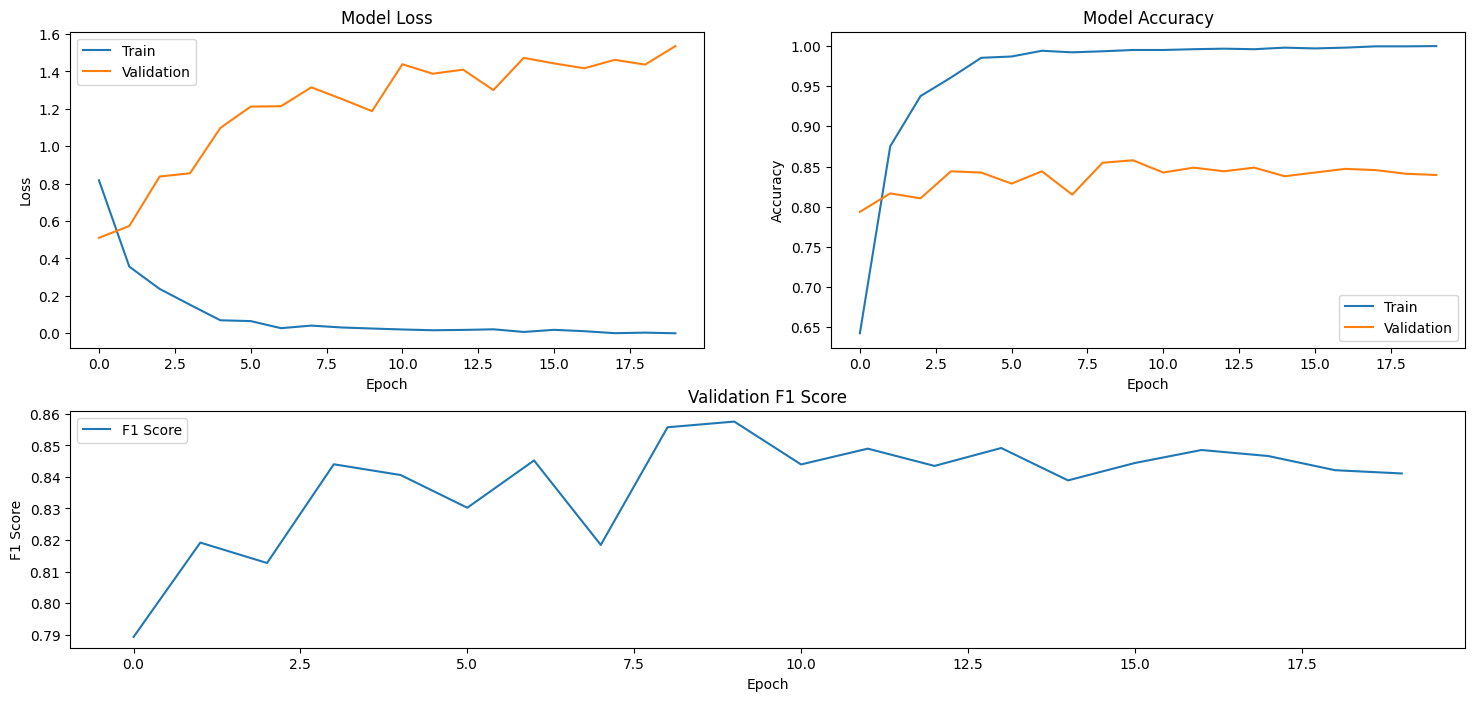

In [ ]:
def plot_training(history_loss_train, history_loss_val,
                  history_acc_train, history_acc_val,
                  history_f1_val):
    fig, axs = plt.subplots(2, 2, figsize=(18, 8),
                            gridspec_kw={"height_ratios": [2, 1]})

    # Remove lower two subplots and replace by one
    axs[1, 0].remove()
    axs[1, 1].remove()
    ax_bottom = fig.add_subplot(2, 1, 2)

    # Loss
    axs[0, 0].plot(history_loss_train, label="Train")
    axs[0, 0].plot(history_loss_val, label="Validation")
    axs[0, 0].set_title("Model Loss")
    axs[0, 0].set_ylabel("Loss")
    axs[0, 0].set_xlabel("Epoch")
    axs[0, 0].legend()

    # Accuracy
    axs[0, 1].plot(history_acc_train, label="Train")
    axs[0, 1].plot(history_acc_val, label="Validation")
    axs[0, 1].set_title("Model Accuracy")
    axs[0, 1].set_ylabel("Accuracy")
    axs[0, 1].set_xlabel("Epoch")
    axs[0, 1].legend()

    # F1
    ax_bottom.plot(history_f1_val)
    ax_bottom.set_title("Validation F1 Score")
    ax_bottom.set_ylabel("F1 Score")
    ax_bottom.set_xlabel("Epoch")
    ax_bottom.legend(["F1 Score"], loc="upper left")

    plt.subplots_adjust(hspace=0.6)
    plt.show()

plot_training(
    train_loss_history,
    val_loss_history,
    train_acc_history,
    val_acc_history,
    val_f1_history,
)

## Load best checkpoint and evaluate on test set

In [ ]:
# Load the best checkpointed model from disk (saved during training when val F1 was highest).
best_model = BertForSequenceClassification.from_pretrained(SAVE_PATH)
# Move it to the appropriate device (GPU/CPU).
best_model.to(device)
# Put the model into evaluation mode (turns off dropout, etc.).
best_model.eval()

# Lists to collect predictions and true labels over the entire test set.
all_test_preds = []
all_test_labels = []

# No gradient computation needed for pure inference.
with torch.no_grad():
    for batch in test_loader:
        # Move batch to device.
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass through the best model (no labels argument here).
        outputs = best_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        logits = outputs.logits

        # Predicted class is the argmax over the logits.
        preds = torch.argmax(logits, dim=-1)

        # Move predictions and labels back to CPU and store as NumPy arrays.
        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

# Print a detailed classification report: precision/recall/F1 per class.
print(
    classification_report(
        all_test_labels,
        all_test_preds,
        target_names=["negative", "neutral", "positive"],
    )
)

# Compute the overall weighted F1 score on the test set.
test_f1 = f1_score(all_test_labels, all_test_preds, average="weighted")
print("Test F1 Score:", test_f1)

# Log the final test F1 to Weights & Biases.
wandb.log({"test_f1_score": test_f1})

              precision    recall  f1-score   support

    negative       0.80      0.80      0.80        81
     neutral       0.88      0.86      0.87       388
    positive       0.78      0.81      0.79       185

    accuracy                           0.84       654
   macro avg       0.82      0.82      0.82       654
weighted avg       0.84      0.84      0.84       654

Test F1 Score: 0.8398820131117897


### Implementation notes: Keras vs PyTorch

This PyTorch version mirrors the earlier Keras solution but shifts where the “magic” lives. The main differences:

- **Training loop**
  - *Keras*: `model.compile(...)` + `model.fit(...)` handled the full training loop (epochs, batches, forward pass, loss, backward pass, optimizer step, metric aggregation) and called callbacks automatically.
  - *PyTorch*: We write the loop manually:
    - `for epoch in range(num_epochs):`
    - `for step, batch in train_loader:`
    - `optimizer.zero_grad()`, `outputs = model(...)`, `loss.backward()`, `optimizer.step()`, `scheduler.step()`
    - Manual tracking of loss/accuracy and calling `evaluate(model, val_loader)` each epoch.

- **Metrics, F1, and early stopping**
  - *Keras*: A custom callback computed F1 on the validation set, saved the best model, added `val_f1_score` to the logs, and `EarlyStopping` monitored that key. W&B logging was handled by `WandbCallback`.
  - *PyTorch*: We define an `evaluate` function that loops over a `DataLoader`, computes loss/accuracy/F1 with `sklearn`, and we:
    - Track `best_val_f1` ourselves and save the model when it improves.
    - Implement early stopping with a simple `patience` counter.
    - Call `wandb.log({...})` directly inside the training loop.

- **Datasets and batching**
  - *Keras*: Tokenized arrays were wrapped in a `tf.data.Dataset`, then `.batch(8)` was passed straight to `model.fit`, which handled iteration and device placement.
  - *PyTorch*: We define a custom `FinancialSentimentDataset` and wrap it in `DataLoader` objects for train/validation/test. We then explicitly iterate over `for batch in train_loader` and move tensors to the device with `.to(device)`.

- **Loss definition**
  - *Keras*: We explicitly chose `SparseCategoricalCrossentropy(from_logits=True)` and passed it to `model.compile`.
  - *PyTorch (HuggingFace)*: `BertForSequenceClassification` computes the cross-entropy loss internally when called with `labels=labels`, and returns `outputs.loss` and `outputs.logits`.

- **Learning rate schedule**
  - *Keras*: Used a `tf.keras.optimizers.schedules.ExponentialDecay` passed directly as the optimizer’s `learning_rate`.
  - *PyTorch*: Uses `AdamW` with a base LR and a separate `get_linear_schedule_with_warmup(...)` scheduler; we must remember to call `scheduler.step()` after each optimizer step.

- **W&B integration**
  - *Keras*: `WandbCallback` automatically picked up losses and metrics from `fit`.
  - *PyTorch*: We initialize the run with `wandb.init(...)`, call `wandb.watch(model, ...)` once, and explicitly log metrics (including test F1) via `wandb.log(...)`.
